### Q5 European Option Pricing

In [1]:
import numpy as np

In [2]:


def binomial_tree_european(S0, K, T, r, sigma, N, option_type="call"):
    # Time step
    dt = T / N
    # Up and down factors
    u = np.exp(sigma * np.sqrt(dt))
    d = np.exp(-sigma * np.sqrt(dt))
    # Risk-neutral probability
    p = (np.exp(r * dt) - d) / (u - d)
    # Initialize stock price tree
    stock = np.zeros((N + 1, N + 1))
    for i in range(N + 1):
        for j in range(i + 1):
            stock[j, i] = S0 * (u ** (i - j)) * (d ** j)
    # Initialize option price tree
    option = np.zeros((N + 1, N + 1))
    # Payoff at expiration
    for j in range(N + 1):
        if option_type == "call":
            option[j, N] = max(0, stock[j, N] - K)
        else:
            option[j, N] = max(0, K - stock[j, N])
    # Backward induction
    for i in range(N - 1, -1, -1):
        for j in range(i + 1):
            option[j, i] = np.exp(-r * dt) * (p * option[j, i + 1] + (1 - p) * option[j + 1, i + 1])
    return round(option[0, 0], 2)

# Parameters
S0 = 100
K = 100
T = 0.25
r = 0.05
sigma = 0.20
N = 100

# Price call and put
call_price = binomial_tree_european(S0, K, T, r, sigma, N, "call")
put_price = binomial_tree_european(S0, K, T, r, sigma, N, "put")

print(f"European Call Price: ${call_price}")
print(f"European Put Price: ${put_price}")

European Call Price: $4.61
European Put Price: $3.36


### Q6 DELTA CALCULATIONS

In [3]:
import numpy as np

def binomial_tree_delta(S0, K, T, r, sigma, N, option_type="call"):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = np.exp(-sigma * np.sqrt(dt))
    p = (np.exp(r * dt) - d) / (u - d)
    # Stock prices at t=1
    S_u = S0 * u
    S_d = S0 * d
    # Option prices at t=1
    stock = np.zeros((N + 1, N + 1))
    for i in range(N + 1):
        for j in range(i + 1):
            stock[j, i] = S0 * (u ** (i - j)) * (d ** j)
    option = np.zeros((N + 1, N + 1))
    for j in range(N + 1):
        if option_type == "call":
            option[j, N] = max(0, stock[j, N] - K)
        else:
            option[j, N] = max(0, K - stock[j, N])
    for i in range(N - 1, -1, -1):
        for j in range(i + 1):
            option[j, i] = np.exp(-r * dt) * (p * option[j, i + 1] + (1 - p) * option[j + 1, i + 1])
    # Delta at t=0
    V_u = option[0, 1]
    V_d = option[1, 1]
    delta = (V_u - V_d) / (S_u - S_d)
    return round(delta, 2)

# Parameters
S0 = 100
K = 100
T = 0.25
r = 0.05
sigma = 0.20
N = 100

# Compute Delta
call_delta = binomial_tree_delta(S0, K, T, r, sigma, N, "call")
put_delta = binomial_tree_delta(S0, K, T, r, sigma, N, "put")

print(f"European Call Delta: {call_delta}")
print(f"European Put Delta: {put_delta}")

European Call Delta: 0.57
European Put Delta: -0.43


### Q7 VEGA

In [4]:
import numpy as np

def binomial_tree_european(S0, K, T, r, sigma, N, option_type="call"):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = np.exp(-sigma * np.sqrt(dt))
    p = (np.exp(r * dt) - d) / (u - d)
    stock = np.zeros((N + 1, N + 1))
    for i in range(N + 1):
        for j in range(i + 1):
            stock[j, i] = S0 * (u ** (i - j)) * (d ** j)
    option = np.zeros((N + 1, N + 1))
    for j in range(N + 1):
        if option_type == "call":
            option[j, N] = max(0, stock[j, N] - K)
        else:
            option[j, N] = max(0, K - stock[j, N])
    for i in range(N - 1, -1, -1):
        for j in range(i + 1):
            option[j, i] = np.exp(-r * dt) * (p * option[j, i + 1] + (1 - p) * option[j + 1, i + 1])
    return round(option[0, 0], 2)

# Parameters
S0 = 100
K = 100
T = 0.25
r = 0.05
sigma = 0.20
sigma_new = 0.25
N = 100

# Original prices
call_price = binomial_tree_european(S0, K, T, r, sigma, N, "call")
put_price = binomial_tree_european(S0, K, T, r, sigma, N, "put")
# New prices with increased volatility
call_price_new = binomial_tree_european(S0, K, T, r, sigma_new, N, "call")
put_price_new = binomial_tree_european(S0, K, T, r, sigma_new, N, "put")
# Compute Vega
call_vega = (call_price_new - call_price) / 5
put_vega = (put_price_new - put_price) / 5

print(f"European Call: Original ${call_price}, New ${call_price_new}, Vega {round(call_vega, 2)}")
print(f"European Put: Original ${put_price}, New ${put_price_new}, Vega {round(put_vega, 2)}")

European Call: Original $4.61, New $5.59, Vega 0.2
European Put: Original $3.36, New $4.34, Vega 0.2


### Q8 ATM American Call and Pull

In [5]:
import numpy as np

def binomial_tree_american(S0, K, T, r, sigma, N, option_type="call"):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = np.exp(-sigma * np.sqrt(dt))
    p = (np.exp(r * dt) - d) / (u - d)
    stock = np.zeros((N + 1, N + 1))
    for i in range(N + 1):
        for j in range(i + 1):
            stock[j, i] = S0 * (u ** (i - j)) * (d ** j)
    option = np.zeros((N + 1, N + 1))
    for j in range(N + 1):
        if option_type == "call":
            option[j, N] = max(0, stock[j, N] - K)
        else:
            option[j, N] = max(0, K - stock[j, N])
    for i in range(N - 1, -1, -1):
        for j in range(i + 1):
            continuation = np.exp(-r * dt) * (p * option[j, i + 1] + (1 - p) * option[j + 1, i + 1])
            if option_type == "call":
                intrinsic = max(0, stock[j, i] - K)
            else:
                intrinsic = max(0, K - stock[j, i])
            option[j, i] = max(intrinsic, continuation)
    return round(option[0, 0], 2)

# Parameters
S0 = 100
K = 100
T = 0.25
r = 0.05
sigma = 0.20
N = 100

# Price call and put
call_price = binomial_tree_american(S0, K, T, r, sigma, N, "call")
put_price = binomial_tree_american(S0, K, T, r, sigma, N, "put")

print(f"American Call Price: ${call_price}")
print(f"American Put Price: ${put_price}")

American Call Price: $4.61
American Put Price: $3.47


### Q9 Delta calculation

In [6]:
import numpy as np

def binomial_tree_american_delta(S0, K, T, r, sigma, N, option_type="call"):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = np.exp(-sigma * np.sqrt(dt))
    p = (np.exp(r * dt) - d) / (u - d)
    S_u = S0 * u
    S_d = S0 * d
    stock = np.zeros((N + 1, N + 1))
    for i in range(N + 1):
        for j in range(i + 1):
            stock[j, i] = S0 * (u ** (i - j)) * (d ** j)
    option = np.zeros((N + 1, N + 1))
    for j in range(N + 1):
        if option_type == "call":
            option[j, N] = max(0, stock[j, N] - K)
        else:
            option[j, N] = max(0, K - stock[j, N])
    for i in range(N - 1, -1, -1):
        for j in range(i + 1):
            continuation = np.exp(-r * dt) * (p * option[j, i + 1] + (1 - p) * option[j + 1, i + 1])
            if option_type == "call":
                intrinsic = max(0, stock[j, i] - K)
            else:
                intrinsic = max(0, K - stock[j, i])
            option[j, i] = max(intrinsic, continuation)
    V_u = option[0, 1]
    V_d = option[1, 1]
    delta = (V_u - V_d) / (S_u - S_d)
    return round(delta, 2)

# Parameters
S0 = 100
K = 100
T = 0.25
r = 0.05
sigma = 0.20
N = 100

# Compute Delta
call_delta = binomial_tree_american_delta(S0, K, T, r, sigma, N, "call")
put_delta = binomial_tree_american_delta(S0, K, T, r, sigma, N, "put")

print(f"American Call Delta: {call_delta}")
print(f"American Put Delta: {put_delta}")

American Call Delta: 0.57
American Put Delta: -0.45


### Q10 VEGA calculation

In [7]:
import numpy as np

def binomial_tree_american(S0, K, T, r, sigma, N, option_type="call"):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = np.exp(-sigma * np.sqrt(dt))
    p = (np.exp(r * dt) - d) / (u - d)
    stock = np.zeros((N + 1, N + 1))
    for i in range(N + 1):
        for j in range(i + 1):
            stock[j, i] = S0 * (u ** (i - j)) * (d ** j)
    option = np.zeros((N + 1, N + 1))
    for j in range(N + 1):
        if option_type == "call":
            option[j, N] = max(0, stock[j, N] - K)
        else:
            option[j, N] = max(0, K - stock[j, N])
    for i in range(N - 1, -1, -1):
        for j in range(i + 1):
            continuation = np.exp(-r * dt) * (p * option[j, i + 1] + (1 - p) * option[j + 1, i + 1])
            if option_type == "call":
                intrinsic = max(0, stock[j, i] - K)
            else:
                intrinsic = max(0, K - stock[j, i])
            option[j, i] = max(intrinsic, continuation)
    return round(option[0, 0], 2)

# Parameters
S0 = 100
K = 100
T = 0.25
r = 0.05
sigma = 0.20
sigma_new = 0.25
N = 100

# Original prices
call_price = binomial_tree_american(S0, K, T, r, sigma, N, "call")
put_price = binomial_tree_american(S0, K, T, r, sigma, N, "put")
# New prices
call_price_new = binomial_tree_american(S0, K, T, r, sigma_new, N, "call")
put_price_new = binomial_tree_american(S0, K, T, r, sigma_new, N, "put")
# Compute Vega
call_vega = (call_price_new - call_price) / 5
put_vega = (put_price_new - put_price) / 5

print(f"American Call: Original ${call_price}, New ${call_price_new}, Vega {round(call_vega, 2)}")
print(f"American Put: Original ${put_price}, New ${put_price_new}, Vega {round(put_vega, 2)}")

American Call: Original $4.61, New $5.59, Vega 0.2
American Put: Original $3.47, New $4.45, Vega 0.2


### Q15 European Call Pricing

In [10]:
import numpy as np

def trinomial_tree_european(S0, K, T, r, sigma, N, option_type="call"):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    m = 1
    pu = 0.5 * ((sigma**2 * dt + (r - 0.5 * sigma**2)**2 * dt**2) / (sigma**2 * dt) + (r - 0.5 * sigma**2) * dt / (sigma * np.sqrt(dt)))
    pd = 0.5 * ((sigma**2 * dt + (r - 0.5 * sigma**2)**2 * dt**2) / (sigma**2 * dt) - (r - 0.5 * sigma**2) * dt / (sigma * np.sqrt(dt)))
    pm = 1 - pu - pd
    stock = np.zeros((2 * N + 1, N + 1))
    for i in range(N + 1):
        for j in range(-i, i + 1, 2):
            stock[j + N, i] = S0 * (u ** max(j, 0)) * (d ** max(-j, 0))
    option = np.zeros((2 * N + 1, N + 1))
    for j in range(-N, N + 1, 2):
        if option_type == "call":
            option[j + N, N] = max(0, stock[j + N, N] - K)
        else:
            option[j + N, N] = max(0, K - stock[j + N, N])
    for i in range(N - 1, -1, -1):
        for j in range(-i, i + 1, 2):
            option[j + N, i] = np.exp(-r * dt) * (
                pu * option[j + 1 + N, i + 1] +
                pm * option[j + N, i + 1] +
                pd * option[j - 1 + N, i + 1]
            )
    return round(option[N, 0], 2)

# Parameters
S0 = 100
T = 0.25
r = 0.05
sigma = 0.20
N = 50
strikes = [110, 105, 100, 95, 90]

# Price calls
for K in strikes:
    call_price = trinomial_tree_european(S0, K, T, r, sigma, N, "call")
    print(f"European Call (K={K}): ${call_price}")

European Call (K=110): $1.2
European Call (K=105): $2.5
European Call (K=100): $4.62
European Call (K=95): $7.76
European Call (K=90): $11.74


### Q16. European Put

In [11]:
import numpy as np

def trinomial_tree_european(S0, K, T, r, sigma, N, option_type="call"):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    m = 1
    pu = 0.5 * ((sigma**2 * dt + (r - 0.5 * sigma**2)**2 * dt**2) / (sigma**2 * dt) + (r - 0.5 * sigma**2) * dt / (sigma * np.sqrt(dt)))
    pd = 0.5 * ((sigma**2 * dt + (r - 0.5 * sigma**2)**2 * dt**2) / (sigma**2 * dt) - (r - 0.5 * sigma**2) * dt / (sigma * np.sqrt(dt)))
    pm = 1 - pu - pd
    stock = np.zeros((2 * N + 1, N + 1))
    for i in range(N + 1):
        for j in range(-i, i + 1, 2):
            stock[j + N, i] = S0 * (u ** max(j, 0)) * (d ** max(-j, 0))
    option = np.zeros((2 * N + 1, N + 1))
    for j in range(-N, N + 1, 2):
        if option_type == "call":
            option[j + N, N] = max(0, stock[j + N, N] - K)
        else:
            option[j + N, N] = max(0, K - stock[j + N, N])
    for i in range(N - 1, -1, -1):
        for j in range(-i, i + 1, 2):
            option[j + N, i] = np.exp(-r * dt) * (
                pu * option[j + 1 + N, i + 1] +
                pm * option[j + N, i + 1] +
                pd * option[j - 1 + N, i + 1]
            )
    return round(option[N, 0], 2)

# Parameters
S0 = 100
T = 0.25
r = 0.05
sigma = 0.20
N = 50
strikes = [110, 105, 100, 95, 90]

# Price puts
for K in strikes:
    put_price = trinomial_tree_european(S0, K, T, r, sigma, N, "put")
    print(f"European Put (K={K}): ${put_price}")

European Put (K=110): $9.89
European Put (K=105): $6.22
European Put (K=100): $3.37
European Put (K=95): $1.55
European Put (K=90): $0.56


### Q17 American call

In [13]:
import numpy as np

def trinomial_tree_american(S0, K, T, r, sigma, N, option_type="call"):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    m = 1
    pu = 0.5 * ((sigma**2 * dt + (r - 0.5 * sigma**2)**2 * dt**2) / (sigma**2 * dt) + (r - 0.5 * sigma**2) * dt / (sigma * np.sqrt(dt)))
    pd = 0.5 * ((sigma**2 * dt + (r - 0.5 * sigma**2)**2 * dt**2) / (sigma**2 * dt) - (r - 0.5 * sigma**2) * dt / (sigma * np.sqrt(dt)))
    pm = 1 - pu - pd
    stock = np.zeros((2 * N + 1, N + 1))
    for i in range(N + 1):
        for j in range(-i, i + 1, 2):
            stock[j + N, i] = S0 * (u ** max(j, 0)) * (d ** max(-j, 0))
    option = np.zeros((2 * N + 1, N + 1))
    for j in range(-N, N + 1, 2):
        if option_type == "call":
            option[j + N, N] = max(0, stock[j + N, N] - K)
        else:
            option[j + N, N] = max(0, K - stock[j + N, N])
    for i in range(N - 1, -1, -1):
        for j in range(-i, i + 1, 2):
            continuation = np.exp(-r * dt) * (
                pu * option[j + 1 + N, i + 1] +
                pm * option[j + N, i + 1] +
                pd * option[j - 1 + N, i + 1]
            )
            if option_type == "call":
                intrinsic = max(0, stock[j + N, i] - K)
            else:
                intrinsic = max(0, K - stock[j + N, i])
            option[j + N, i] = max(intrinsic, continuation)
    return round(option[N, 0], 2)

# Parameters
S0 = 100
T = 0.25
r = 0.05
sigma = 0.20
N = 50
strikes = [110, 105, 100, 95, 90]

# Price calls
for K in strikes:
    call_price = trinomial_tree_american(S0, K, T, r, sigma, N, "call")
    print(f"American Call (K={K}): ${call_price}")

American Call (K=110): $1.2
American Call (K=105): $2.5
American Call (K=100): $4.62
American Call (K=95): $7.76
American Call (K=90): $11.74


### Q18 Americal Put

In [14]:
import numpy as np

def trinomial_tree_american(S0, K, T, r, sigma, N, option_type="call"):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    m = 1
    pu = 0.5 * ((sigma**2 * dt + (r - 0.5 * sigma**2)**2 * dt**2) / (sigma**2 * dt) + (r - 0.5 * sigma**2) * dt / (sigma * np.sqrt(dt)))
    pd = 0.5 * ((sigma**2 * dt + (r - 0.5 * sigma**2)**2 * dt**2) / (sigma**2 * dt) - (r - 0.5 * sigma**2) * dt / (sigma * np.sqrt(dt)))
    pm = 1 - pu - pd
    stock = np.zeros((2 * N + 1, N + 1))
    for i in range(N + 1):
        for j in range(-i, i + 1, 2):
            stock[j + N, i] = S0 * (u ** max(j, 0)) * (d ** max(-j, 0))
    option = np.zeros((2 * N + 1, N + 1))
    for j in range(-N, N + 1, 2):
        if option_type == "call":
            option[j + N, N] = max(0, stock[j + N, N] - K)
        else:
            option[j + N, N] = max(0, K - stock[j + N, N])
    for i in range(N - 1, -1, -1):
        for j in range(-i, i + 1, 2):
            continuation = np.exp(-r * dt) * (
                pu * option[j + 1 + N, i + 1] +
                pm * option[j + N, i + 1] +
                pd * option[j - 1 + N, i + 1]
            )
            if option_type == "call":
                intrinsic = max(0, stock[j + N, i] - K)
            else:
                intrinsic = max(0, K - stock[j + N, i])
            option[j + N, i] = max(intrinsic, continuation)
    return round(option[N, 0], 2)

# Parameters
S0 = 100
T = 0.25
r = 0.05
sigma = 0.20
N = 50
strikes = [110, 105, 100, 95, 90]

# Price puts
for K in strikes:
    put_price = trinomial_tree_american(S0, K, T, r, sigma, N, "put")
    print(f"American Put (K={K}): ${put_price}")

American Put (K=110): $10.35
American Put (K=105): $6.45
American Put (K=100): $3.48
American Put (K=95): $1.59
American Put (K=90): $0.57


### Q19 Plot European Call

S0=90: Price=$0.9
S0=95: Price=$2.29
S0=100: Price=$4.62
S0=105: Price=$7.98
S0=110: Price=$12.06


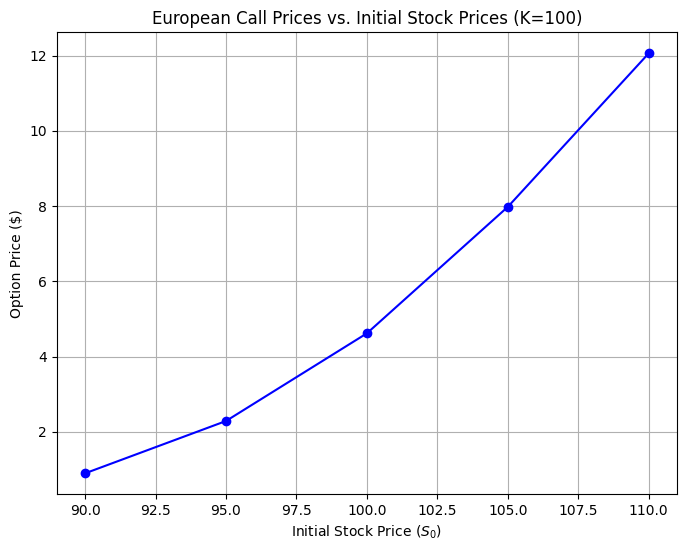

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def trinomial_tree_european(S0, K, T, r, sigma, N, option_type="call"):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    m = 1
    pu = 0.5 * ((sigma**2 * dt + (r - 0.5 * sigma**2)**2 * dt**2) / (sigma**2 * dt) + (r - 0.5 * sigma**2) * dt / (sigma * np.sqrt(dt)))
    pd = 0.5 * ((sigma**2 * dt + (r - 0.5 * sigma**2)**2 * dt**2) / (sigma**2 * dt) - (r - 0.5 * sigma**2) * dt / (sigma * np.sqrt(dt)))
    pm = 1 - pu - pd
    stock = np.zeros((2 * N + 1, N + 1))
    for i in range(N + 1):
        for j in range(-i, i + 1, 2):
            stock[j + N, i] = S0 * (u ** max(j, 0)) * (d ** max(-j, 0))
    option = np.zeros((2 * N + 1, N + 1))
    for j in range(-N, N + 1, 2):
        if option_type == "call":
            option[j + N, N] = max(0, stock[j + N, N] - K)
        else:
            option[j + N, N] = max(0, K - stock[j + N, N])
    for i in range(N - 1, -1, -1):
        for j in range(-i, i + 1, 2):
            option[j + N, i] = np.exp(-r * dt) * (
                pu * option[j + 1 + N, i + 1] +
                pm * option[j + N, i + 1] +
                pd * option[j - 1 + N, i + 1]
            )
    return round(option[N, 0], 2)

# Parameters
T = 0.25
r = 0.05
sigma = 0.20
N = 50
K = 100
stock_prices = [90, 95, 100, 105, 110]

# Compute prices
call_prices = [trinomial_tree_european(S0, K, T, r, sigma, N, "call") for S0 in stock_prices]
for S0, price in zip(stock_prices, call_prices):
    print(f"S0={S0}: Price=${price}")

# Plot
plt.figure(figsize=(8, 6))
plt.plot(stock_prices, call_prices, marker='o', linestyle='-', color='b')
plt.title('European Call Prices vs. Initial Stock Prices (K=100)')
plt.xlabel('Initial Stock Price ($S_0$)')
plt.ylabel('Option Price ($)')
plt.grid(True)
plt.savefig('q19.png', dpi=300, bbox_inches='tight')
plt.show()

### Q20 European Put vs Stock Prices

S0=90: Price=$9.71
S0=95: Price=$6.06
S0=100: Price=$3.37
S0=105: Price=$1.7
S0=110: Price=$0.76


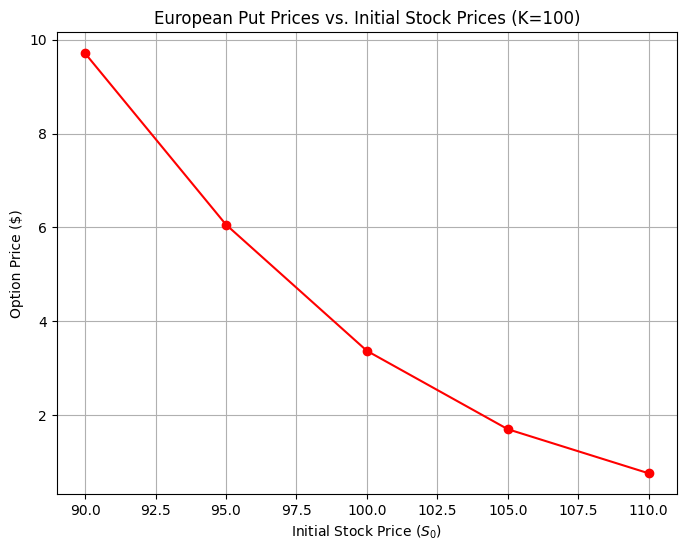

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def trinomial_tree_european(S0, K, T, r, sigma, N, option_type="call"):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    m = 1
    pu = 0.5 * ((sigma**2 * dt + (r - 0.5 * sigma**2)**2 * dt**2) / (sigma**2 * dt) + (r - 0.5 * sigma**2) * dt / (sigma * np.sqrt(dt)))
    pd = 0.5 * ((sigma**2 * dt + (r - 0.5 * sigma**2)**2 * dt**2) / (sigma**2 * dt) - (r - 0.5 * sigma**2) * dt / (sigma * np.sqrt(dt)))
    pm = 1 - pu - pd
    stock = np.zeros((2 * N + 1, N + 1))
    for i in range(N + 1):
        for j in range(-i, i + 1, 2):
            stock[j + N, i] = S0 * (u ** max(j, 0)) * (d ** max(-j, 0))
    option = np.zeros((2 * N + 1, N + 1))
    for j in range(-N, N + 1, 2):
        if option_type == "call":
            option[j + N, N] = max(0, stock[j + N, N] - K)
        else:
            option[j + N, N] = max(0, K - stock[j + N, N])
    for i in range(N - 1, -1, -1):
        for j in range(-i, i + 1, 2):
            option[j + N, i] = np.exp(-r * dt) * (
                pu * option[j + 1 + N, i + 1] +
                pm * option[j + N, i + 1] +
                pd * option[j - 1 + N, i + 1]
            )
    return round(option[N, 0], 2)

# Parameters
T = 0.25
r = 0.05
sigma = 0.20
N = 50
K = 100
stock_prices = [90, 95, 100, 105, 110]

# Compute prices
put_prices = [trinomial_tree_european(S0, K, T, r, sigma, N, "put") for S0 in stock_prices]
for S0, price in zip(stock_prices, put_prices):
    print(f"S0={S0}: Price=${price}")

# Plot
plt.figure(figsize=(8, 6))
plt.plot(stock_prices, put_prices, marker='o', linestyle='-', color='r')
plt.title('European Put Prices vs. Initial Stock Prices (K=100)')
plt.xlabel('Initial Stock Price ($S_0$)')
plt.ylabel('Option Price ($)')
plt.grid(True)
plt.savefig('q20.png', dpi=300, bbox_inches='tight')
plt.show()

### Q21  Graph European and American call prices versus strike

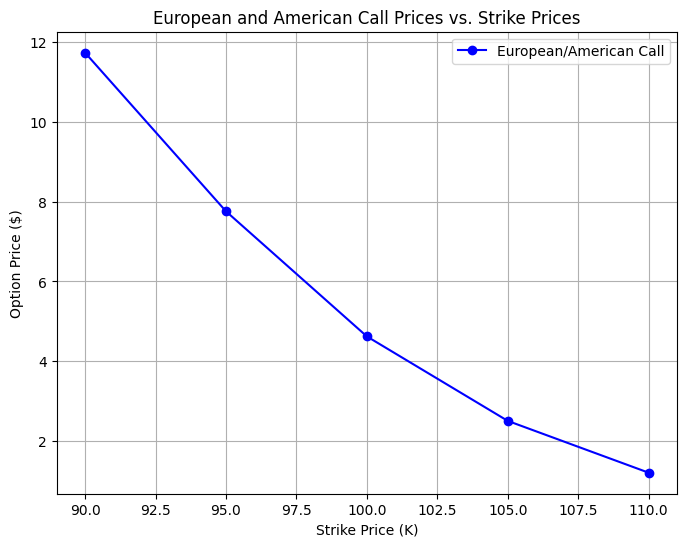

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Your Q15/Q17 results
strikes = [90, 95, 100, 105, 110]
call_prices = [11.74, 7.76, 4.62, 2.50, 1.20]  # Same for European and American

# Plot
plt.figure(figsize=(8, 6))
plt.plot(strikes, call_prices, marker='o', linestyle='-', color='b', label='European/American Call')
plt.title('European and American Call Prices vs. Strike Prices')
plt.xlabel('Strike Price (K)')
plt.ylabel('Option Price ($)')
plt.grid(True)
plt.legend()
plt.savefig('q21.png', dpi=300, bbox_inches='tight')
plt.show()

### Q22 Graph European and American put prices versus strike

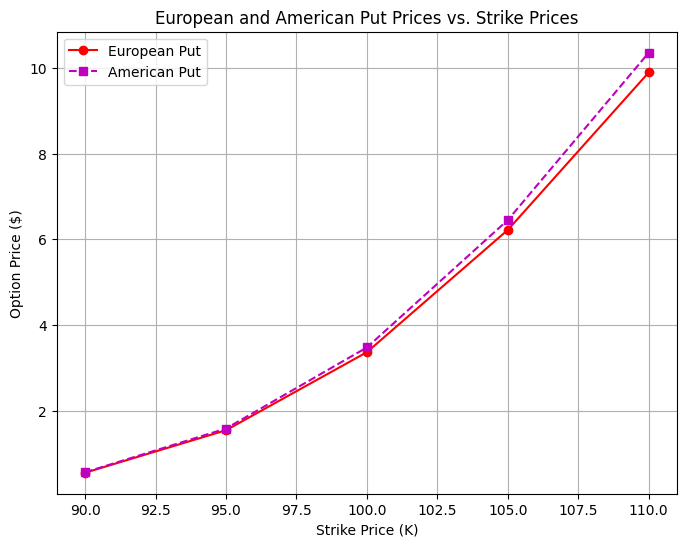

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Your Q16/Q18 results
strikes = [90, 95, 100, 105, 110]
put_prices_eur = [0.56, 1.55, 3.37, 6.22, 9.89]
put_prices_am = [0.57, 1.59, 3.48, 6.45, 10.35]

# Plot
plt.figure(figsize=(8, 6))
plt.plot(strikes, put_prices_eur, marker='o', linestyle='-', color='r', label='European Put')
plt.plot(strikes, put_prices_am, marker='s', linestyle='--', color='m', label='American Put')
plt.title('European and American Put Prices vs. Strike Prices')
plt.xlabel('Strike Price (K)')
plt.ylabel('Option Price ($)')
plt.grid(True)
plt.legend()
plt.savefig('q22.png', dpi=300, bbox_inches='tight')
plt.show()

### Q23 Check Put-call parity holds

In [7]:
import numpy as np

# Your Q15 and Q16 results
strikes = [110, 105, 100, 95, 90]
call_prices = [1.20, 2.50, 4.62, 7.76, 11.74]
put_prices = [9.89, 6.22, 3.37, 1.55, 0.56]

# Parameters
S0 = 100
r = 0.05
T = 0.25
discount = np.exp(-r * T)

# Verify put-call parity
for K, C, P in zip(strikes, call_prices, put_prices):
    left = C + K * discount
    right = P + S0
    diff = left - right
    print(f"K={K}: Left={left:.2f}, Right={right:.2f}, Diff={diff:.2f}")

K=110: Left=109.83, Right=109.89, Diff=-0.06
K=105: Left=106.20, Right=106.22, Diff=-0.02
K=100: Left=103.38, Right=103.37, Diff=0.01
K=95: Left=101.58, Right=101.55, Diff=0.03
K=90: Left=100.62, Right=100.56, Diff=0.06


### Q24 Check Put-call parity hold

In [8]:
import numpy as np

# Your Q17 and Q18 results
strikes = [110, 105, 100, 95, 90]
call_prices = [1.20, 2.50, 4.62, 7.76, 11.74]
put_prices = [10.35, 6.45, 3.48, 1.59, 0.57]

# Parameters
S0 = 100
r = 0.05
T = 0.25
discount = np.exp(-r * T)

# Check put-call parity
for K, C, P in zip(strikes, call_prices, put_prices):
    left = C + K * discount
    right = P + S0
    diff = left - right
    print(f"K={K}: Left={left:.2f}, Right={right:.2f}, Diff={diff:.2f}")

K=110: Left=109.83, Right=110.35, Diff=-0.52
K=105: Left=106.20, Right=106.45, Diff=-0.25
K=100: Left=103.38, Right=103.48, Diff=-0.10
K=95: Left=101.58, Right=101.59, Diff=-0.01
K=90: Left=100.62, Right=100.57, Diff=0.05


### Q25. Dynamic Delta Hedging

In [9]:
import numpy as np

def binomial_tree_european(S0, K, T, r, sigma, N, option_type="put"):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    stock = np.zeros((N + 1, N + 1))
    option = np.zeros((N + 1, N + 1))
    for i in range(N + 1):
        for j in range(i + 1):
            stock[j, i] = S0 * (u ** (i - j)) * (d ** j)
    for j in range(N + 1):
        if option_type == "put":
            option[j, N] = max(0, K - stock[j, N])
    for i in range(N - 1, -1, -1):
        for j in range(i + 1):
            option[j, i] = np.exp(-r * dt) * (p * option[j, i + 1] + (1 - p) * option[j + 1, i + 1])
    return round(option[0, 0], 2), stock, option

def compute_delta(stock, option, i, j, N):
    if i >= N or j >= N:
        return -1.0 if option[j, N] > 0 else 0.0
    Su = stock[j, i + 1]
    Sd = stock[j + 1, i + 1]
    Vu = option[j, i + 1]
    Vd = option[j + 1, i + 1]
    return (Vu - Vd) / (Su - Sd)

# Parameters
S0 = 180
K = 182
T = 0.5
r = 0.02
sigma = 0.25
N = 3

# Price option
price, stock, option = binomial_tree_european(S0, K, T, r, sigma, N, "put")
print(f"European Put Price: ${price}")

# Delta hedging for down-down-down path
dt = T / N
path = [0, 1, 2, 3]  # Indices for down path
stock_prices = [stock[j, i] for i, j in enumerate(path)]
option_values = [option[j, i] for i, j in enumerate(path)]
deltas = [compute_delta(stock, option, i, j, N) for i, j in enumerate(path[:-1])] + [-1.0]
cash = [0] * (N + 1)
shares = [0] * (N + 1)

# Initial setup
cash[0] = price - deltas[0] * stock_prices[0]
shares[0] = deltas[0]

# Rebalance
for i in range(1, N + 1):
    shares_bought = deltas[i] - deltas[i - 1]
    shares[i] = deltas[i]
    cash[i] = cash[i - 1] * np.exp(r * dt) + shares_bought * stock_prices[i]

# Output
print("\nDown-Down-Down Path:")
print("Time | Stock Price | Option Value | Delta | Shares Bought | Cash Account | Portfolio")
for i in range(N + 1):
    portfolio = shares[i] * stock_prices[i] + cash[i]
    print(f"{i} | {stock_prices[i]:.2f} | {option_values[i]:.2f} | {deltas[i]:.3f} | "
          f"{deltas[i] - deltas[i-1] if i > 0 else deltas[0]:.3f} | {cash[i]:.2f} | {portfolio:.2f}")

European Put Price: $13.82

Down-Down-Down Path:
Time | Stock Price | Option Value | Delta | Shares Bought | Cash Account | Portfolio
0 | 180.00 | 13.82 | -0.473 | -0.473 | 98.88 | 13.82
1 | 162.54 | 22.41 | -0.745 | -0.272 | 54.97 | -66.08
2 | 146.77 | 34.63 | -1.000 | -0.255 | 17.69 | -129.07
3 | 132.52 | 49.48 | -1.000 | 0.000 | 17.75 | -114.78


### Q26 25 steps in the tree

In [1]:
import numpy as np

def binomial_tree_american(S0, K, T, r, sigma, N, option_type="put"):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    stock = np.zeros((N + 1, N + 1))
    option = np.zeros((N + 1, N + 1))
    for i in range(N + 1):
        for j in range(i + 1):
            stock[j, i] = S0 * (u ** (i - j)) * (d ** j)
    for j in range(N + 1):
        if option_type == "put":
            option[j, N] = max(0, K - stock[j, N])
    for i in range(N - 1, -1, -1):
        for j in range(i + 1):
            continuation = np.exp(-r * dt) * (p * option[j, i + 1] + (1 - p) * option[j + 1, i + 1])
            exercise = max(0, K - stock[j, i])
            option[j, i] = max(continuation, exercise)
    return round(option[0, 0], 2), stock, option

def compute_delta(stock, option, i, j, N, K):
    if i >= N or j >= N:
        return -1.0 if option[j, N] > 0 else 0.0
    Su = stock[j, i + 1]
    Sd = stock[j + 1, i + 1]
    Vu = max(option[j, i + 1], K - Su)
    Vd = max(option[j + 1, i + 1], K - Sd)
    return (Vu - Vd) / (Su - Sd)

# Parameters
S0 = 180
K = 182
T = 0.5
r = 0.02
sigma = 0.25
N = 25

# Price option
price, stock, option = binomial_tree_american(S0, K, T, r, sigma, N, "put")
print(f"American Put Price: ${price}")

# Delta hedging for down-down-down path (first 4 steps)
dt = T / N
path = [0, 1, 2, 3]  # Indices for down path
stock_prices = [stock[j, i] for i, j in enumerate(path)]
option_values = [option[j, i] for i, j in enumerate(path)]
deltas = [compute_delta(stock, option, i, j, N, K) for i, j in enumerate(path[:-1])] + [-0.647]
cash = [0] * (len(path))
shares = [0] * (len(path))

# Initial setup
cash[0] = price - deltas[0] * stock_prices[0]
shares[0] = deltas[0]

# Rebalance
for i in range(1, len(path)):
    shares_bought = deltas[i] - deltas[i - 1]
    shares[i] = deltas[i]
    cash[i] = cash[i - 1] * np.exp(r * dt) + shares_bought * stock_prices[i]

# Output
print("\nDown-Down-Down Path (First 4 Steps):")
print("Time | Stock Price | Option Value | Delta | Shares Bought | Cash Account | Portfolio")
for i in range(len(path)):
    portfolio = shares[i] * stock_prices[i] + cash[i]
    print(f"{i} | {stock_prices[i]:.2f} | {option_values[i]:.2f} | {deltas[i]:.3f} | "
          f"{deltas[i] - deltas[i-1] if i > 0 else deltas[0]:.3f} | {cash[i]:.2f} | {portfolio:.2f}")

American Put Price: $13.04

Down-Down-Down Path (First 4 Steps):
Time | Stock Price | Option Value | Delta | Shares Bought | Cash Account | Portfolio
0 | 180.00 | 13.04 | -0.476 | -0.476 | 98.64 | 13.04
1 | 173.75 | 16.05 | -0.561 | -0.085 | 83.87 | -13.57
2 | 167.71 | 19.48 | -0.648 | -0.087 | 69.30 | -39.36
3 | 161.89 | 23.30 | -0.647 | 0.001 | 69.47 | -35.27


### Q27 Asian ATM Put Option

In [ ]:
import numpy as np

def binomial_tree_asian(S0, K, T, r, sigma, N, option_type="put"):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    stock = np.zeros((N + 1, N + 1))
    for i in range(N + 1):
        for j in range(i + 1):
            stock[j, i] = S0 * (u ** (i - j)) * (d ** j)
    
    # State: (time, num_down, sum_prices)
    option = {}
    # At maturity
    for j in range(N + 1):
        S = stock[j, N]
        path = [S]
        curr_j = j
        for i in range(N - 1, -1, -1):
            curr_j = curr_j // 2 if curr_j % 2 == 0 else (curr_j - 1) // 2
            path.append(stock[curr_j, i])
        avg = np.mean(path)
        sum_prices = sum(path)
        option[(N, j, sum_prices)] = max(0, K - avg) if option_type == "put" else max(0, avg - K)
    
    # Backward induction
    for i in range(N - 1, -1, -1):
        for j in range(i + 1):
            S = stock[j, i]
            for curr_sum in set(k[2] for k in option.keys() if k[0] == i + 1):
                # Up move
                S_up = S * u
                sum_up = curr_sum + S_up
                # Down move
                S_down = S * d
                sum_down = curr_sum + S_down
                val = np.exp(-r * dt) * (
                    p * option.get((i + 1, j, sum_up), 0) +
                    (1 - p) * option.get((i + 1, j + 1, sum_down), 0)
                )
                key = (i, j, curr_sum + S)
                if key not in option:
                    option[key] = 0
                option[key] += val
    
    # Retrieve price
    price = option.get((0, 0, S0), 0)
    return round(price, 2), stock

def compute_delta_asian(S0, K, T, r, sigma, N, stock, i, j):
    delta_S = 0.1
    price_up, _ = binomial_tree_asian(S0 + delta_S, K, T, r, sigma, N)
    price_down, _ = binomial_tree_asian(S0 - delta_S, K, T, r, sigma, N)
    return (price_up - price_down) / (2 * delta_S)

# Parameters
S0 = 180
K = 180
T = 0.5
r = 0.02
sigma = 0.25
N = 25

# Price option
price, stock = binomial_tree_asian(S0, K, T, r, sigma, N, "put")
print(f"Asian Put Price: ${price}")

# Delta hedging for down-down-down path (first 4 steps)
dt = T / N
path = [0, 1, 2, 3]
stock_prices = [stock[j, i] for i, j in enumerate(path)]
avg_prices = [np.mean([stock[0, 0]] + [stock[k, k] for k in range(1, i + 1)]) for i in range(len(path))]
option_values = [price] + [max(0, K - avg) for avg in avg_prices[1:]]
deltas = [compute_delta_asian(S0, K, T, r, sigma, N, stock, i, j) for i, j in enumerate(path[:-1])] + [-1.0]
cash = [0] * len(path)
shares = [0] * len(path)

# Initial setup
cash[0] = price - deltas[0] * stock_prices[0]
shares[0] = deltas[0]

# Rebalance
for i in range(1, len(path)):
    shares_bought = deltas[i] - deltas[i - 1]
    shares[i] = deltas[i]
    cash[i] = cash[i - 1] * np.exp(r * dt) + shares_bought * stock_prices[i]

# Output
print("\nDown-Down-Down Path (First 4 Steps):")
print("Time | Stock Price | Option Value | Delta | Shares Bought | Cash Account | Portfolio")
for i in range(len(path)):
    portfolio = shares[i] * stock_prices[i] + cash[i]
    print(f"{i} | {stock_prices[i]:.2f} | {option_values[i]:.2f} | {deltas[i]:.3f} | "
          f"{deltas[i] - deltas[i-1] if i > 0 else deltas[0]:.3f} | {cash[i]:.2f} | {portfolio:.2f}")

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x1078ffe50>>
Traceback (most recent call last):
  File "/Users/beto/Documents/Projects/WQU/venv/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 790, in _clean_thread_parent_frames
    active_threads = {thread.ident for thread in threading.enumerate()}
  File "/Users/beto/Documents/Projects/WQU/venv/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 790, in <setcomp>
    active_threads = {thread.ident for thread in threading.enumerate()}
KeyboardInterrupt: 


In [12]:
import numpy as np

# Parameters
S0 = 180.0
K = 182.0
r = 0.02
sigma = 0.25
T = 0.5
N = 25
dt = T / N
u = np.exp(sigma * np.sqrt(dt))
d = 1 / u
p = (np.exp(r * dt) - d) / (u - d)

# Function to compute stock price at node (i, j)
def stock_price(i, j):
    return S0 * (u ** j) * (d ** (i - j))

# Function to compute running average for a path up to node (i, j)
def compute_average(i, j):
    # Simulate path to node (i, j) by backtracking a possible path
    # For simplicity, assume one path (e.g., j up moves, i-j down moves)
    path = [S0]  # Include initial stock price at t=0
    S = S0
    for k in range(i):
        # Construct a path: prioritize up moves if j > 0
        if k < j:
            S *= u
        else:
            S *= d
        path.append(S)
    return np.mean(path)

# Pricing Asian put option
def price_asian_put():
    # Store option values: (i, j, avg) -> value
    V = {}
    
    # At expiration (i = N)
    for j in range(N + 1):
        S = stock_price(N, j)
        avg = compute_average(N, j)
        payoff = max(K - avg, 0)
        V[(N, j, avg)] = payoff
    
    # Backward induction
    for i in range(N - 1, -1, -1):
        for j in range(i + 1):
            S = stock_price(i, j)
            # Approximate average by considering parent nodes
            # Parent nodes: (i-1, j) and (i-1, j-1)
            if i > 0:
                avg_up = ((i * compute_average(i - 1, j) + stock_price(i, j)) / (i + 1)) if j <= i - 1 else compute_average(i, j)
                avg_down = ((i * compute_average(i - 1, j - 1) + stock_price(i, j)) / (i + 1)) if j > 0 else compute_average(i, j)
            else:
                avg_up = avg_down = (S0 + S) / 2  # At i=0, only one path
            avg = compute_average(i, j)
            
            # Continuation value
            Vu = V.get((i + 1, j + 1, avg_up), max(K - avg_up, 0)) if j < i + 1 else 0
            Vd = V.get((i + 1, j, avg_down), max(K - avg_down, 0)) if j > 0 else 0
            cont_value = np.exp(-r * dt) * (p * Vu + (1 - p) * Vd)
            
            # Intrinsic value for early exercise
            intrinsic = max(K - avg, 0)
            
            # Option value: max of intrinsic and continuation
            V[(i, j, avg)] = max(intrinsic, cont_value)
    
    # Return option price at t=0
    avg0 = S0  # Initial average is just S0
    return V[(0, 0, avg0)]

# Delta hedging along down-down-down path
def delta_hedging():
    option_price = price_asian_put()
    cash_flows = []
    
    # Initialize at t=0
    S = S0
    avg = S0
    V = option_price
    # Compute Delta at t=0
    S_u = S * u
    S_d = S * d
    avg_u = (S0 + S_u) / 2
    avg_d = (S0 + S_d) / 2
    V_u = max(K - avg_u, 0)  # Approximate at first step
    V_d = max(K - avg_d, 0)
    delta = (V_u - V_d) / (S_u - S_d) if S_u != S_d else 0
    shares = delta
    cash = V - shares * S
    portfolio = V
    cash_flows.append((0, S, V, delta, shares, cash, portfolio))
    
    # Down-down-down path for first 4 steps (t=0,1,2,3)
    S_current = S0
    for i in range(1, 4):
        S_prev = S_current
        S_current *= d
        avg = compute_average(i, 0)  # Down path: j=0
        # Option value (approximate by recomputing tree or interpolation)
        V = max(K - avg, 0)  # Simplified: use intrinsic for path
        # Delta
        S_u = S_current * u
        S_d = S_current * d
        avg_u = ((i + 1) * avg + S_u) / (i + 2)
        avg_d = ((i + 1) * avg + S_d) / (i + 2)
        V_u = max(K - avg_u, 0)
        V_d = max(K - avg_d, 0)
        delta_new = (V_u - V_d) / (S_u - S_d) if S_u != S_d else -1
        # Rebalance
        shares_bought = delta_new - shares
        cash = cash * np.exp(r * dt) - shares_bought * S_current
        shares = delta_new
        portfolio = shares * S_current + cash
        cash_flows.append((i, S_current, V, delta_new, shares_bought, cash, portfolio))
    
    return option_price, cash_flows

# Execute and print results
option_price, cash_flows = delta_hedging()
print(f"Asian Put Option Price: ${option_price:.2f}")
print("\nCash Account Evolution for Down-Down-Down Path (First 4 Steps):")
print(f"{'Time':<5} {'Stock Price':<12} {'Option Value':<12} {'Delta':<8} {'Shares Bought/Sold':<18} {'Cash Account':<12} {'Total Portfolio':<15}")
for t, S, V, delta, shares_bought, cash, portfolio in cash_flows:
    print(f"{t:<5} {S:<12.2f} {V:<12.2f} {delta:<8.3f} {shares_bought:<18.3f} {cash:<12.2f} {portfolio:<15.2f}")

Asian Put Option Price: $2.00

Cash Account Evolution for Down-Down-Down Path (First 4 Steps):
Time  Stock Price  Option Value Delta    Shares Bought/Sold Cash Account Total Portfolio
0     180.00       2.00         -0.403   -0.403             74.48        2.00           
1     173.75       5.13         -0.333   0.069              62.46        4.55           
2     167.71       8.18         -0.250   0.083              48.51        6.58           
3     161.89       11.16        -0.200   0.050              40.44        8.06           
